In [1]:
import numpy as np
import math
from scipy import constants
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
# defining all the functions

def wavenumber(n, wavelength):
    """
    Outputs the angular wavenumber for propagation of a wave
    Args:
        n (float): index of refraction of the medium
        wavelength (float): the wavelength of the wave in nanometres
    Returns:
        k (float): the wavenumber
    """
    wavelength = wavelength * (10**-9) # converts to metres
    k = (2 * math.pi * n)/wavelength # calculates k
    return k

def rho(x, y):
    """
    Finds rho for a gaussian beam
    Args:
        x (float): x coordinate
        y (float): y coordinate
    Returns:
        rho (float): the value of rho at (x,y)
    """
    rho = np.sqrt((x**2)+(y**2))
    return rho

def rayleigh_range(omega_0, wavelength):
    """
    Finds the rayleigh range for a given beam waist radius
    Args:
        omega_0 (float): the waist radius
        wavelength (float): wavelength of the beam in nm
    Returns:
        confocal_parameter (float): the rayleigh range z_0
    """
    wavelength = wavelength * (10**-9) # converts wavelength to metres
    confocal_parameter = (np.pi * (omega_0**2))/wavelength
    return confocal_parameter

def omega_z(omega_0, z, wavelength):
    """
    Calculates omega(z)
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
    Returns:
        beam_width (float): omega(z) for given args
    """
    square_of_ratio = (z/rayleigh_range(omega_0, wavelength))**2 # finds (z/z_0)^2
    beam_width = omega_0 * np.sqrt(1+square_of_ratio) # w(z) = w_0*(1+(z/z_0)^2)^0.5
    return beam_width

def radius_of_curvature(omega_0, z, wavelength):
    """
    Calculates the radius of curvature of the wavefront
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
    Returns:
        R_z (float): the radius of curvature of the wavefront at z
    """
    square_of_ratio = (rayleigh_range(omega_0, wavelength)/z)**2 # (z_0/z)^2
    R_z = z * (1 + square_of_ratio)
    return R_z

def zeta_function(omega_0, z, wavelength):
    """
    Performs the relevant zeta function to gaussian beams
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
    Returns:
        zeta_z (float): the relevant zeta function
    """
    zeta_z = np.atan(z/rayleigh_range(omega_0, wavelength)) # arctan(z/z_0)
    return zeta_z

def gaussian_beam(omega_0, z, wavelength, a_0, x, y, n):
    """
    Finds the value for the complex electric field of a given gaussian beam at a given point from creation
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
        a_0 (float): the electric field amplitude at the origin
        x (float): the x coordinate
        y (float): the y coordinate
        n (float): the index of refraction of the medium
    Returns:
        amplitude (float): the amplitude of the wave
        phase (float): the phase of the wave
    """
    amplitude = a_0 * (omega_0/omega_z(omega_0, z, wavelength)) * (np.e**(-(rho(x, y)**2)/(omega_z(omega_0, z, wavelength))**2))
    phase = math.e**(complex(0,-1) * (wavenumber(n, wavelength) * z + ((wavenumber(n, wavelength) * (rho(x, y)) ** 2)/(2 * radius_of_curvature(omega_0, z, wavelength))) - zeta_function(omega_0, z, wavelength)))
    return amplitude, phase

def gaussian_beam_rho(omega_0, z, wavelength, a_0, rho_1, n):
    """
    Finds the value for the complex electric field of a given gaussian beam at a given point from creation
    Args:
        omega_0 (float): the waist radius
        z (float): the coordinate in direction of beam propagation
        wavelength (float): wavelength of the beam in nm
        a_0 (float): the electric field amplitude at the origin
        rho_1 (float): a precalculated rho value
        n (float): the index of refraction of the medium
    Returns:
        E_z_rho: the value of the electric field for the given point and beam
    """
    amplitude = a_0 * (omega_0/omega_z(omega_0, z, wavelength)) * (np.e**-(rho_1**2/(omega_z(omega_0, z, wavelength))**2))
    phase = math.e**(complex(0,-1) * (wavenumber(n, wavelength) * z + ((wavenumber(n, wavelength) * (rho_1 ** 2)/(2 * radius_of_curvature(omega_0, z, wavelength))) - zeta_function(omega_0, z, wavelength))))
    return amplitude, phase

def fwhm(x,y):
    """
    Finds the full width at half maximum of the graph
    Args:
        x (np.array): x coord
        y (np.array): y coord
    Returns:
        fw_hm (float): full width at half maximum
    """
    # Target y-value
    target_y = np.max(y)/2
    
    # Find indices where y crosses target_y
    # This detects sign changes in (y - target_y)
    indices = np.where(np.diff(np.sign(y - target_y)) != 0)[0]
    
    # Interpolate to find more accurate x-values
    x_at_target = []
    for i in indices:
        x0, x1 = x[i], x[i+1]
        y0, y1 = y[i], y[i+1]
        # Linear interpolation formula
        x_cross = x0 + (target_y - y0) * (x1 - x0) / (y1 - y0)
        x_at_target.append(x_cross)
    fw_hm = np.sum(abs(np.array(x_at_target)))
    return float(fw_hm)

Below is the code specific to this system

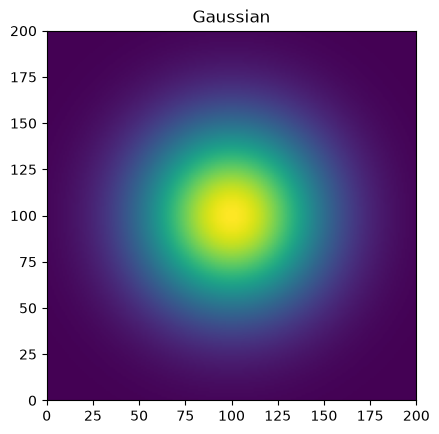

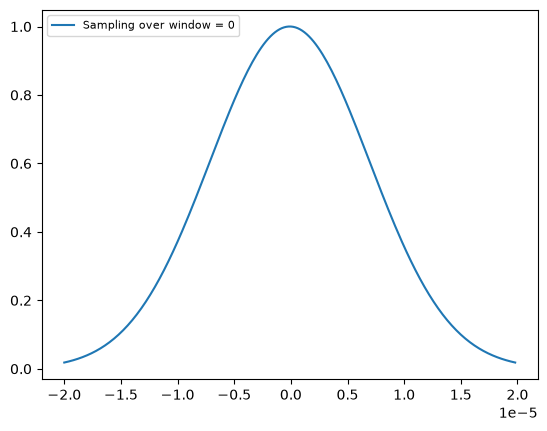

In [7]:
# sets initial parameters of the beam

wavelength = 29
omega_0 = 1e-5
z = 1e-10 # at the source
a_0 = 100
n = 1
variable = omega_0 * 2


# defines a meshgrid of xy values and calculates the beam at this point

initial_beam_x = np.linspace(-variable,variable,200)
initial_beam_y = np.linspace(-variable,variable,200)
x_mesh, y_mesh = np.meshgrid(initial_beam_x, initial_beam_y)
amp, phase = gaussian_beam(omega_0, z, wavelength, a_0, x_mesh, y_mesh, n)

# plots this as an image in 2D to be observed
plt.figure()
plt.imshow(amp, extent = [0,len(amp), 0, len(amp[0])], origin = 'lower')
plt.title('Gaussian')
plt.show()
    
marginal = np.sum(amp, 0)
plt.plot(np.linspace(-variable,variable,200, endpoint = False), marginal/np.max(marginal), '-', label = (f'Sampling over window = {int(2*variable)}'))
plt.legend(fontsize = 8, loc = 2)
plt.show()

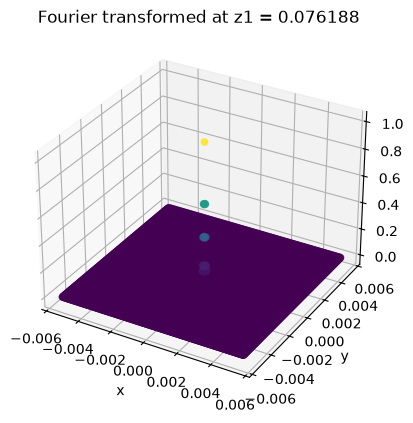

In [10]:
def calculate_2dft(input):
    """
    Calculates the 2D Fast Fourier Transform of an image
    Args:
        input (nested np.array): the nested array of values that come out of the gaussian_beam function
    Returns:
        np.fft.ifftshift(ft_1) (nested np.array): the fourier transformed arrays
    """
    ft = np.fft.ifftshift(input) # shifts the input
    ft_1 = np.fft.fft2(ft) # performs 2D fft
    return np.fft.fftshift(ft_1) # inverse shifts

# does the 2D fourier transform and normalises the values
ft = calculate_2dft(amp)
ft_norm = abs(ft)/np.max(abs(ft))

z1=0.076188 # defining a length far beyond the Fraunhofer condition for the parameters set

# defines a new meshgrid of xy coordinates to enable plotting in 3D, including the corrections needed for Fraunhofer diffraction

dx = initial_beam_x[1]-initial_beam_x[0]
x_post_fft = np.fft.fftshift(np.fft.fftfreq(len(ft), d=dx))
x_post_fft_corr = x_post_fft*wavelength*1e-9*z1
 
dy = initial_beam_x[1]-initial_beam_x[0]
y_post_fft = np.fft.fftshift(np.fft.fftfreq(len(ft), d=dy))
y_post_fft_corr = y_post_fft*wavelength*1e-9*z1

x_mesh_fft, y_mesh_fft = np.meshgrid(x_post_fft_corr,y_post_fft_corr)

#plots the fft of the source ideal beam
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_mesh_fft, y_mesh_fft, abs(ft_norm), c=ft_norm, marker='o', s=20)
plt.title(f'Fourier transformed at z1 = {z1}')
plt.xlabel('x')
plt.ylabel('y')

plt.show()

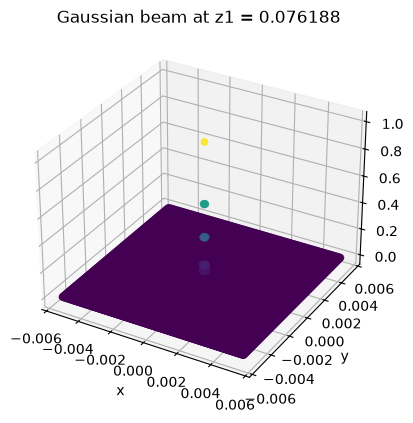

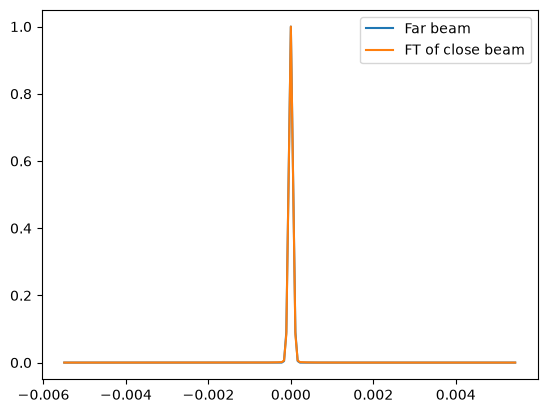

Error = 0.0016421980536762014


In [9]:
# defines a new meshgrid and calculates the beam at this point

x_far = x_post_fft_corr
y_far = y_post_fft_corr
x_far_mesh, y_far_mesh = np.meshgrid(x_far, y_far)
amp_far, phase_far = gaussian_beam(omega_0, z1, wavelength, a_0, x_far_mesh, y_far_mesh, n)

# plots the graph of the beam at z1
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_far_mesh, y_far_mesh, abs(amp_far/np.max(amp_far)), c=amp_far, marker='o', s=20)
plt.title(f'Gaussian beam at z1 = {z1}')
plt.xlabel('x')
plt.ylabel('y')

plt.show()

#--------------------------------------------------------------------------------
fwhm_val = []
marginal_far = np.sum(abs(amp_far), 0)
plt.plot(x_far, marginal_far/np.max(marginal_far), '-', label = 'Far beam')
fwhm_val.append(fwhm(x_far, marginal_far/np.max(marginal_far)))

marginal_fft = np.sum(abs(ft_norm), 0)
plt.plot(x_far ,marginal_fft/np.max(marginal_fft), '-', label = 'FT of close beam')
fwhm_val.append(fwhm(x_far, marginal_fft/np.max(marginal_fft)))

plt.legend(loc = 1)
plt.show()

print(f'Error = {abs((fwhm_val[1] - fwhm_val[0])/fwhm_val[0])}')